In [27]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

# Шаг 1: Загрузка данных
data = pd.read_csv("../data/lb3/Iris.csv")
print(data.head())

   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [28]:

# Преобразование категориальных данных в числовые
le = LabelEncoder()
data['Species'] = le.fit_transform(data['Species'])

# Выбираем признаки для кластеризации
X = data[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].values
y_true = data['Species'].values

# Стандартизация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Кластеры: 2, Силуэтный коэффициент: 0.580
Кластеры: 3, Силуэтный коэффициент: 0.409
Кластеры: 4, Силуэтный коэффициент: 0.257
Кластеры: 5, Силуэтный коэффициент: 0.197
Кластеры: 6, Силуэтный коэффициент: 0.216
Кластеры: 7, Силуэтный коэффициент: 0.089
Кластеры: 8, Силуэтный коэффициент: 0.218
Кластеры: 9, Силуэтный коэффициент: 0.163
Кластеры: 10, Силуэтный коэффициент: 0.195


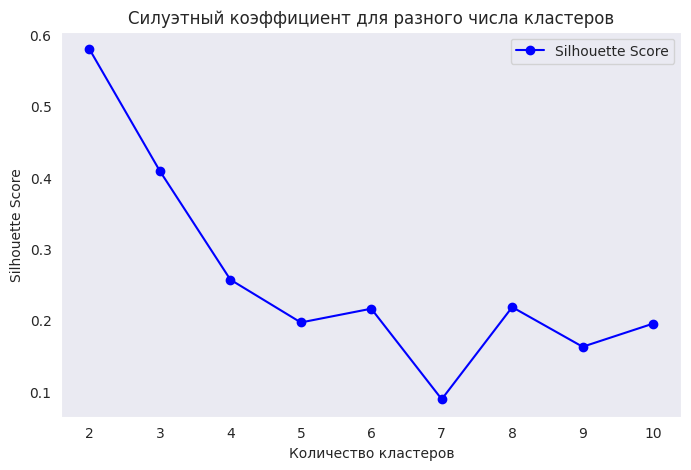

In [29]:
# Определение оптимального числа кластеров с помощью силуэтного коэффициента
silhouette_scores = []
cluster_range = range(2, 11)

for n_clusters in cluster_range:
    gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42)
    labels = gmm.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, labels)
    silhouette_scores.append(silhouette_avg)
    print(f'Кластеры: {n_clusters}, Силуэтный коэффициент: {silhouette_avg:.3f}')

# Построение графика силуэтного коэффициента
plt.figure(figsize=(8, 5))
plt.plot(cluster_range, silhouette_scores, marker='o', linestyle='-', color='blue', label='Silhouette Score')
plt.title('Силуэтный коэффициент для разного числа кластеров')
plt.xlabel('Количество кластеров')
plt.ylabel('Silhouette Score')
plt.xticks(cluster_range)
plt.grid()
plt.legend()
plt.show()

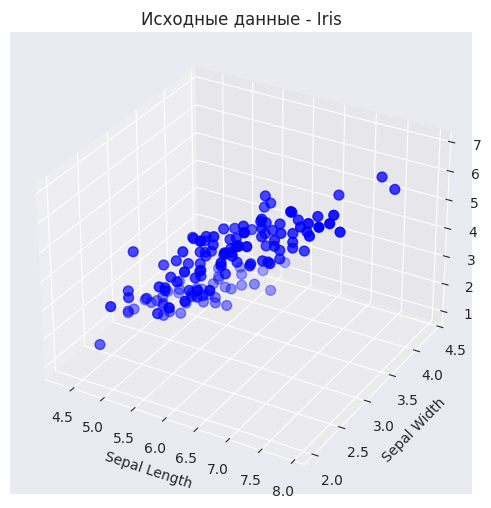

In [30]:

# Шаг 2: Визуализация исходных данных (3D-график)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c='blue', s=50)
ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
plt.title('Исходные данные - Iris')
plt.show()

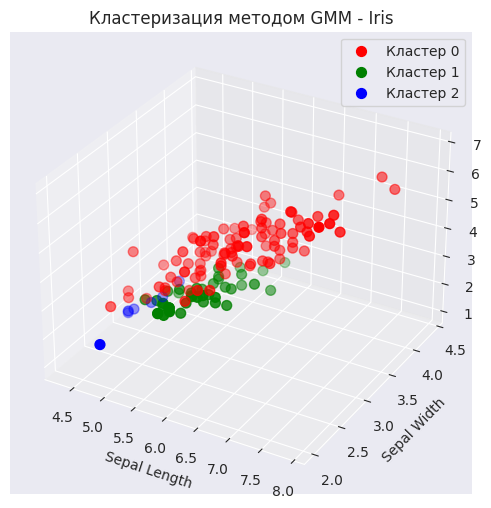

In [31]:

# Шаг 3: Кластеризация методом Gaussian Mixture Model (GMM)
gmm = GaussianMixture(n_components=3, covariance_type='full', random_state=42)
gmm.fit(X_scaled)
labels = gmm.predict(X_scaled)

# Добавляем кластеры в данные
data['Cluster'] = labels

# Шаг 4: Визуализация кластеров (3D-график)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
colors = ['red', 'green', 'blue']
for cluster in np.unique(labels):
    cluster_points = X[labels == cluster]
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1], cluster_points[:, 2], s=50, color=colors[cluster], label=f'Кластер {cluster}')

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
plt.title('Кластеризация методом GMM - Iris')
plt.legend()
plt.show()

In [32]:
# График демонстрирует результаты кластеризации датасета Iris с использованием метода Gaussian Mixture Model (GMM). В результате алгоритм выделил три кластера, обозначенные разными цветами:
# Кластер 0 (красный): точки с высокими значениями длины чашелистика (Sepal Length) и умеренными значениями ширины чашелистика (Sepal Width).
# Кластер 1 (зелёный): точки с умеренными значениями обоих параметров (длина и ширина чашелистика).
# Кластер 2 (синий): точки с меньшими значениями длины чашелистика и относительно высокими значениями ширины чашелистика.
# Алгоритм GMM подходит для данного набора данных, поскольку он позволяет моделировать перекрывающиеся кластеры, учитывая вероятностное распределение точек. Это особенно полезно, поскольку виды ирисов Versicolor и Virginica перекрываются в пространстве признаков, а Setosa чётко отделена.

In [33]:
# 3D-график был выбран для визуализации, поскольку датасет Iris содержит четыре числовых признака. Чтобы наглядно продемонстрировать распределение данных и выделение кластеров, выбраны три наиболее значимых признака:
# Sepal Length (длина чашелистика) — по оси X.
# Sepal Width (ширина чашелистика) — по оси Y.
# Petal Length (длина лепестка) — по оси Z.
# Такое представление позволяет:
# Увидеть трёхмерное распределение точек, что делает визуализацию более информативной по сравнению с плоским графиком.
# Отследить пространственное перекрытие кластеров, особенно между кластерами Versicolor и Virginica.
# Показать плотность точек и пространственные отношения, что особенно полезно для анализа точек, имеющих схожие значения по двум признакам, но различающиеся по третьему.
# Таким образом, 3D-график позволяет более наглядно продемонстрировать, как алгоритм GMM выделяет группы, особенно в случае пересекающихся или слабо отделённых кластеров.

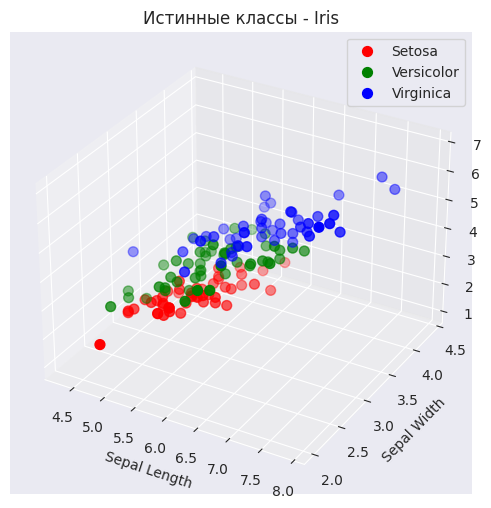

In [34]:

# Шаг 5: Визуализация истинных меток классов (3D-график)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
true_colors = ['red', 'green', 'blue']
species_names = ['Setosa', 'Versicolor', 'Virginica']
for species in np.unique(y_true):
    species_points = X[y_true == species]
    ax.scatter(species_points[:, 0], species_points[:, 1], species_points[:, 2], s=50, color=true_colors[species], label=species_names[species])

ax.set_xlabel('Sepal Length')
ax.set_ylabel('Sepal Width')
ax.set_zlabel('Petal Length')
plt.title('Истинные классы - Iris')
plt.legend()
plt.show()

In [35]:

# Шаг 6: Оценка качества кластеризации
silhouette_avg = silhouette_score(X_scaled, labels)
print(f'Средний силуэтный коэффициент: {silhouette_avg:.3f}')

Средний силуэтный коэффициент: 0.409


In [36]:
# Средний силуэтный коэффициент для кластеризации методом GMM составил 0.409. Это значение указывает на умеренное качество кластеризации, что ожидаемо для данного набора данных. Значение силуэтного коэффициента варьируется от -1 до 1, где:
# Близко к 1 — точки хорошо сгруппированы внутри кластеров и далеко от точек других кластеров.
# Близко к 0 — точки находятся на границе кластеров и могут принадлежать к разным группам.
# Отрицательное значение — точки чаще отнесены не к тому кластеру.
# Значение 0.409 отражает ситуацию, когда кластеры Versicolor и Virginica имеют значительное перекрытие в пространстве признаков. Это объясняется тем, что эти два вида ирисов имеют схожие характеристики длины и ширины лепестков, что затрудняет точное разделение. Алгоритм GMM пытается учесть вероятностные границы кластеров, что делает его более гибким по сравнению с жестким разбиением K-Means. Тем не менее, умеренный силуэтный коэффициент указывает на наличие точек с высокой неопределённостью, которые находятся на границах кластеров.
# Для улучшения качества кластеризации можно было бы попробовать:
# Использовать другие признаки или комбинации признаков.
# Уменьшить размерность данных с помощью PCA, чтобы лучше разделить кластеры.
# Провести дополнительный анализ плотности точек, чтобы понять области перекрытия.
# Таким образом, несмотря на умеренный силуэтный коэффициент, использование GMM оправдано в данном контексте, поскольку он позволяет моделировать пересекающиеся кластеры и демонстрирует гибкость в учете пространственной плотности данных.
